# Producto Tensorial y Esfera de Bloch
- **Estudiante:** Enrique Prada Vázquez
- **Fecha:** 18-05-2026

## Introducción
Este notebook contiene la resolución práctica del Trabajo titulo *Producto Tensorial y Esfera de Bloch* de la asignatura Álgebra Líneal en Computación Cuántica. El objetivo es profundizar en la estructura matemática de los sistemas multiqubit y su representación geométrica. 

La actividad se divide en tres bloques fundamentales:
1.  **Álgebra de Operadores:** Cálculo de productos tensoriales (Kronecker) para matrices unitarias de Pauli.
2.  **Aplicaciones:** Evaluación de operadores compuestos y cálculo de amplitudes de transición entre estados de la base computacional ($|010\rangle$ y $|101\rangle$).
3.  **Visualización:** Uso de la **Esfera de Bloch** para representar estados puros y analizar el efecto rotacional de las puertas cuánticas fundamentales ($X, Y, Z, H$).

## Pautas de Elaboración
De acuerdo con los requisitos:
* Se incluye el código detallado utilizando **NumPy** y **Qiskit**.
* Cada sentencia relevante está comentada con el comando `#` para explicar su función.
* Se presentan las justificaciones matemáticas necesarias para cada ítem.

### Preparación del entorno
*Es necesario ejecutar la siguiente celda para cargar las librerías necesarias y reiniciar el kernel tras la instalación.*

In [14]:
pip install matplotlib numpy qiskit sympy

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sympy]32m1/2 [sympy]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Configuración del Entorno y Definición de Operadores Base

En esta primera sección, se prepara el entorno de trabajo importando las librerías necesarias para el álgebra lineal (**NumPy**) y la computación cuántica (**Qiskit**). 

Se definen las matrices unitarias fundamentales (puertas de Pauli e Identidad) que servirán como base para construir los operadores multiqubit mediante productos tensoriales.

* **Identidad ($I$):** No altera el estado del qubit.
* **Puerta $X$ (NOT):** Realiza un bit-flip (rotación de $\pi$ sobre el eje X).
* **Puerta $Y$:** Rotación de $\pi$ sobre el eje Y.
* **Puerta $Z$:** Realiza un phase-flip (rotación de $\pi$ sobre el eje Z).

In [1]:
import numpy as np
from qiskit.visualization import plot_bloch_multivector, array_to_latex
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from qiskit.quantum_info import Operator
from IPython.display import display
from qiskit.visualization.bloch import Bloch

# Definición de matrices base (Puertas de Pauli e Identidad)
I = np.eye(2) # Matriz Identidad de 2x2
X = np.array([[0, 1], [1, 0]]) # Puerta NOT (X)
Y = np.array([[0, -1j], [1j, 0]]) # Puerta Pauli-Y
Z = np.array([[1, 0], [0, -1]]) # Puerta Pauli-Z

# Visualización

display(array_to_latex(I, prefix="I= "))
display(array_to_latex(X, prefix="X= "))
display(array_to_latex(Y, prefix="Y= "))
display(array_to_latex(Z, prefix="Z= "))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## 2. Cálculo del Producto Tensorial

En esta sección se calculan las matrices resultantes de realizar el producto tensorial (o producto de Kronecker) de diversas combinaciones de matrices unitarias. 

El producto tensorial de dos matrices $A$ (de tamaño $m \times n$) y $B$ (de tamaño $p \times q$) da como resultado una matriz de dimensiones $(m \cdot p) \times (n \cdot q)$. En el contexto de la computación cuántica, esta operación nos permite describir el operador global que actúa sobre un sistema compuesto de varios qubits.

Se calcularán las siguientes tres combinaciones:
1. **$A = X \otimes I \otimes Z \otimes I$**: Operador de 4 qubits (matriz de $16 \times 16$).
2. **$B = I \otimes Y \otimes Z \otimes X$**: Operador de 4 qubits (matriz de $16 \times 16$).
3. **$C = Z \otimes X \otimes I$**: Operador de 3 qubits (matriz de $8 \times 8$).

In [16]:
# Cálculo de X ⊗ I ⊗ Z ⊗ I
M1 = np.kron(np.kron(I, Z), I)
A = np.kron(X, M1)

# Cálculo de I ⊗ Y ⊗ Z ⊗ X
M2 = np.kron(np.kron(Y, Z), X)
B = np.kron(I, M2)

# Cálculo de Z ⊗ X ⊗ I
M3 = np.kron(X, I)
C = np.kron(Z, M3)

display(array_to_latex(M1, prefix="M_1="))
display(array_to_latex(A, prefix="A=", max_size=16 ))
display(array_to_latex(M2, prefix="M_2="))
display(array_to_latex(B, prefix="B=", max_size=16 ))
display(array_to_latex(M3, prefix="M_3="))
display(array_to_latex(C, prefix="C="))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## 3. Aplicaciones del Producto Tensorial

En este apartado, se construye un operador complejo $O$ mediante una combinación lineal. Posteriormente, se evalua la interacción de este operador con estados específicos de la base computacional.

Se define el operador $O$ siguiendo la expresión:
$$O = \frac{2}{3}(X \otimes Z \otimes I) + \frac{1}{4}(I \otimes Z \otimes X) - \frac{5}{6}(Y \otimes Y \otimes Z)$$

### 3.1. Cálculo de la Amplitud de Transición
Se calcula el valor escalar (elemento de matriz) resultante de la operación:
$$\langle 101 | O | 010 \rangle$$

Este cálculo nos indica la "amplitud de probabilidad" de que el sistema pase del estado $|010\rangle$ al estado $|101\rangle$ bajo la acción de $\hat{O}$. Para ello, representamos los kets como vectores de 8 dimensiones y utilizamos el bra (transpuesto conjugado) para el producto matricial.

In [11]:
# Definición del operador combinado
# Basado en la fórmula: 2/3(X⊗Z⊗I) + 1/4(I⊗Z⊗X) - 5/6(Y⊗Y⊗Z)
term1 = (2/3) * np.kron(np.kron(X, Z), I)
term2 = (1/4) * np.kron(np.kron(I, Z), X)
term3 = (5/6) * np.kron(np.kron(Y, Y), Z)
O = term1 + term2 - term3 # Suma ponderada de los operadores

# Definición de kets de la base computacional
k0 = np.array([[1], [0]]) # Estado |0>
k1 = np.array([[0], [1]]) # Estado |1>

# Construcción de los estados de 3 qubits |010> y |101>
ket_010 = np.kron(np.kron(k0, k1), k0) # Estado inicial
ket_101 = np.kron(np.kron(k1, k0), k1) # Estado final deseado
bra_101 = ket_101.conj().T # Transpuesto conjugado (bra) para el cálculo

# Cálculo del elemento de matriz <101|O|010>
resultado_2 = bra_101 @ O @ ket_010 # Producto matricial para obtener el escalar
display("Matriz del operador O (8x8):")
display(array_to_latex(O, prefix="O = "))
display(f"Resultado de la operación <101|O|010>: {resultado_2}")

'Matriz del operador O (8x8):'

<IPython.core.display.Latex object>

'Resultado de la operación <101|O|010>: [[0.+0.j]]'

### 4. Visualización en la esfera de Bloch

Para la representación de los estados cuánticos, se utiliza la **Esfera de Bloch**, un espacio geométrico donde cada estado puro de un qubit se mapea a un punto en la superficie de una esfera de radio unidad.

La posición de cada vector de estado $|\psi\rangle$ se determina mediante sus coordenadas cartesianas $(x, y, z)$, las cuales se obtienen calculando el valor esperado de las matrices de Pauli ($X, Y, Z$) para dicho estado:

* $x = \langle \psi | X | \psi \rangle$
* $y = \langle \psi | Y | \psi \rangle$
* $z = \langle \psi | Z | \psi \rangle$

En este apartado, se representan conjuntamente los autovectores de las tres bases mutuamente imparciales:
1.  **Base Z (Computacional):** $|0\rangle$ y $|1\rangle$.
2.  **Base X (Hadamard):** $|+\rangle$ y $|-\rangle$.
3.  **Base Y (Circular):** $|i+\rangle$ ($|r\rangle$) y $|i-\rangle$ ($|l\rangle$).

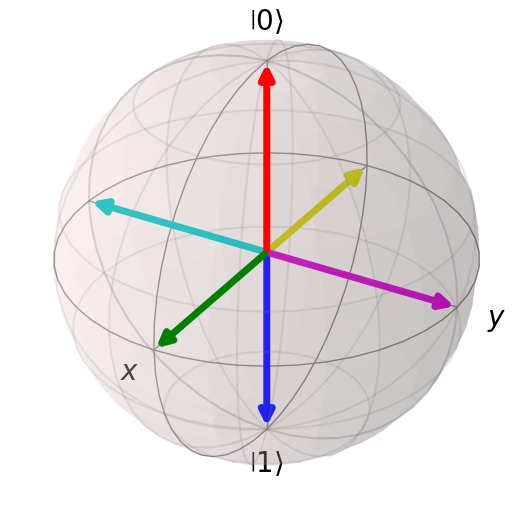

In [25]:
# 1. Definición de los estados (usando Statevector para obtener las coordenadas)
# Se crea una lista para iterar fácilmente
estados = [
    Statevector.from_label('0'),
    Statevector.from_label('1'),
    Statevector.from_label('+'),
    Statevector.from_label('-'),
    Statevector.from_label('r'),
    Statevector.from_label('l')
    ]

# 2. Configuración de la Esfera de Bloch única
esfera = Bloch()
esfera.vector_color = ['r', 'b', 'g', 'y', 'm', 'c'] # Colores distintos para cada vector

for psi in estados:
    # Se extrae el valor esperado de los operadores X, Y, Z para obtener las coordenadas (x, y, z)
    # Esto es lo que define la posición en la esfera
    coord = [
        psi.expectation_value([[0, 1], [1, 0]]).real, # X
        psi.expectation_value([[0, -1j], [1j, 0]]).real, # Y
        psi.expectation_value([[1, 0], [0, -1]]).real # Z
    ]
    esfera.add_vectors(coord)

esfera.show()

## 5. Efecto de las Puertas Cuánticas en la Esfera de Bloch

En esta sección final, se analiza cómo los operadores unitarios fundamentales transforman los estados de la base computacional $|0\rangle$ y $|1\rangle$. En la esfera de Bloch, las puertas cuánticas se interpretan como rotaciones geométricas precisas:

* **Puerta $X$**: Realiza una rotación de $\pi$ radianes sobre el eje $X$. Actúa como un inversor de bits (bit-flip), intercambiando los polos norte y sur ($|0\rangle \leftrightarrow |1\rangle$).
* **Puerta $Y$**: Realiza una rotación de $\pi$ radianes sobre el eje $Y$. Transforma $|0\rangle$ en $i|1\rangle$ y $|1\rangle$ en $-i|0\rangle$.
* **Puerta $Z$**: Realiza una rotación de $\pi$ radianes sobre el eje $Z$. Es un inversor de fase (phase-flip); no altera la posición de $|0\rangle$ o $|1\rangle$ en los polos, pero cambia el signo relativo en estados de superposición.
* **Puerta $H$ (Hadamard)**: Realiza una rotación de $\pi$ sobre el eje diagonal entre $X$ y $Z$. Es la puerta fundamental para generar superposición, mapeando estados de la base $Z$ a la base $X$ ($|0\rangle \to |+\rangle$ y $|1\rangle \to |-\rangle$).

A continuación, se define una función para aplicar estas transformaciones utilizando la clase `Operator` de Qiskit y visualizar el estado resultante mediante el vector de estado evolucionado.

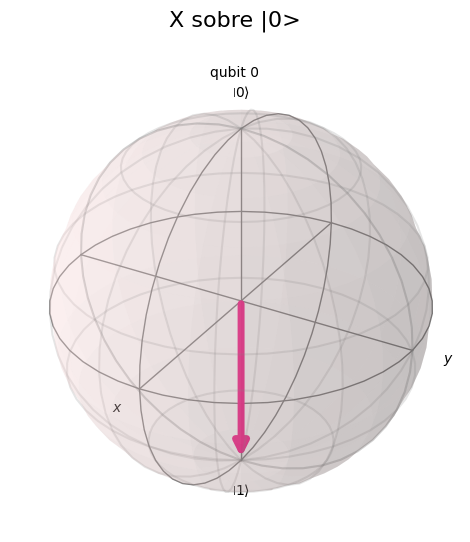

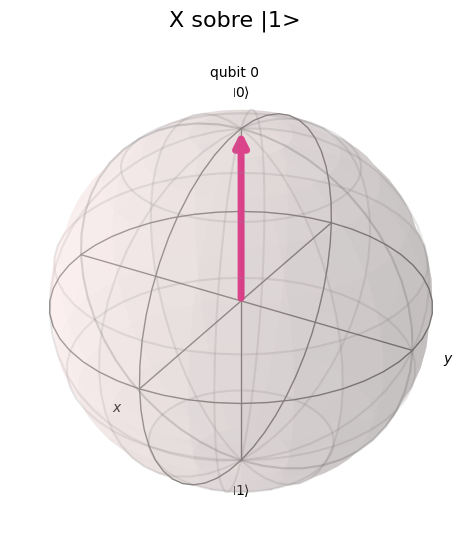

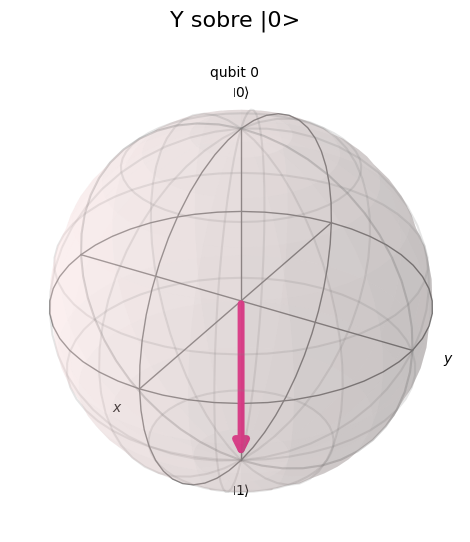

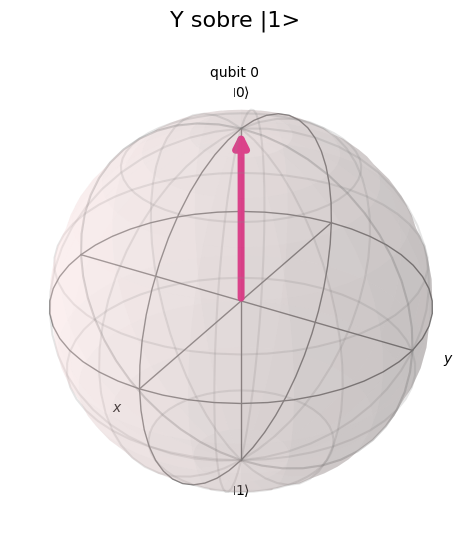

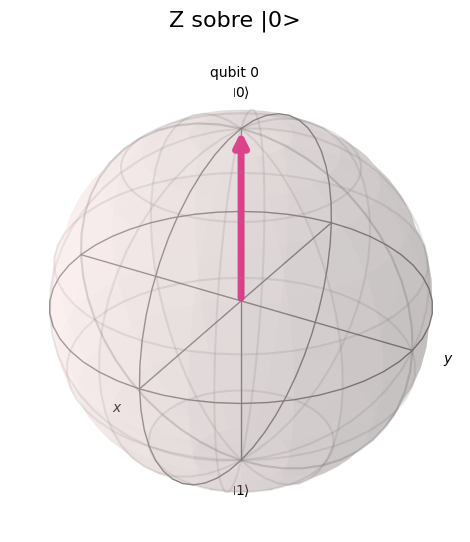

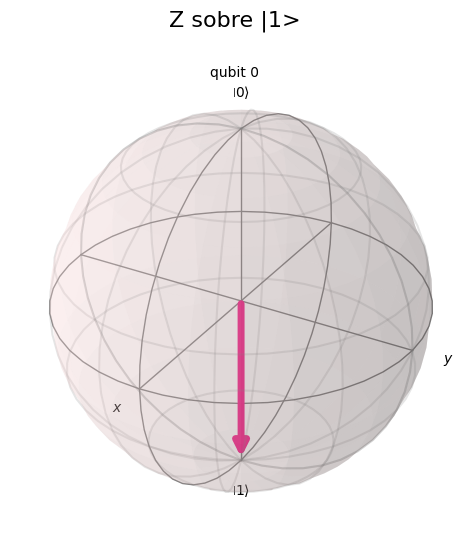

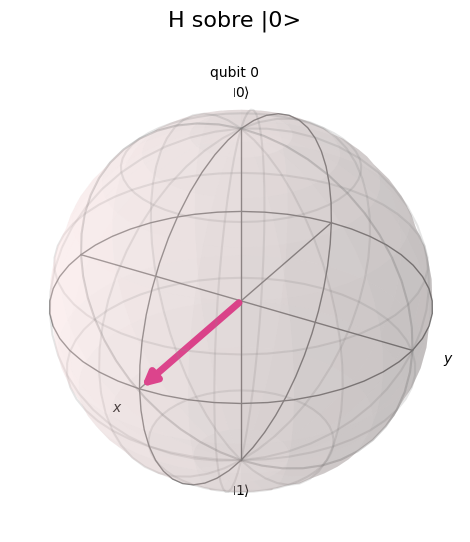

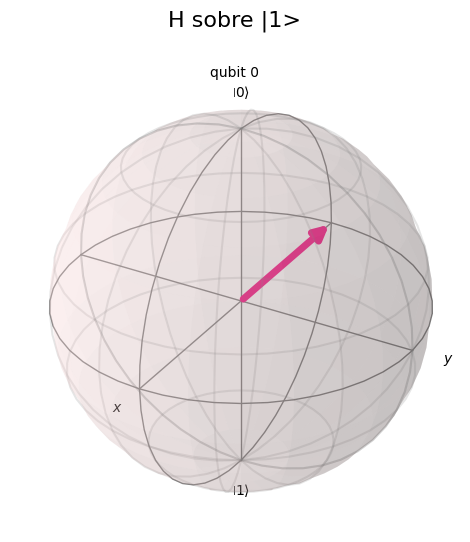

In [5]:
# Definición de estados base
psi0 = Statevector.from_label('0') # Estado |0> [cite: 17, 24]
psi1 = Statevector.from_label('1') # Estado |1> [cite: 18, 24]

# Definición de operadores de las puertas solicitadas
gate_X = Operator(X) # Puerta X 
gate_Y = Operator(Y) # Puerta Y 
gate_Z = Operator(Z) # Puerta Z 
# Uso de la matriz estándar para Hadamard (H)
H_mat = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]])
gate_H = Operator(H_mat)

def visualizar_efecto(puerta, nombre_puerta):
    # Aplicación la puerta a |0> y |1>
    res0 = psi0.evolve(puerta) # Efecto sobre |0> 
    res1 = psi1.evolve(puerta) # Efecto sobre |1> 
    
    # Visualización de resultados
    display(plot_bloch_multivector(res0, title=f"{nombre_puerta} sobre |0>"))
    display(plot_bloch_multivector(res1, title=f"{nombre_puerta} sobre |1>"))

# Ejecución para cada puerta requerida
visualizar_efecto(gate_X, "X") # Puerta X 
visualizar_efecto(gate_Y, "Y") # Puerta Y 
visualizar_efecto(gate_Z, "Z") # Puerta Z 
visualizar_efecto(gate_H, "H") # Puerta H